In [ ]:
import warnings
warnings.filterwarnings("ignore", message=r"Passing", category=FutureWarning)
import os 
import sys 
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P'])
from utilities.traces import get_traces,ridge_plot
from rois.rois import load_mch_ind
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from caiman.base.rois import com
from matplotlib.lines import Line2D

ani = '989N'
fov='FOV1'
session='Baseline'
file_key = '/Volumes/AM_SSD1/Spont2P/Data_info.csv'
base_dir = '/Volumes/AM_SSD1/Spont2P'
mch_pre,mch_post,non_pre,non_post = load_mch_ind(ani,fov,file_key,base_dir)
dff,_,_,smooth=get_traces(ani, fov, session, file_key,base_dir)

dff_mchs = dff[mch_pre,:]
dff_nons = dff[non_pre,:]

/Volumes/AM_SSD1/Caiman/Tagging/989N_FOV1_indices_split.csv
Using cell reg output file: /Volumes/AM_SSD1/Caiman/CellReg/989N_FOV1/cellRegistered_20220613_225153.mat
378 Cells detected in registration
260 Cells detected in session 1 of 2
253 Cells detected in session 2 of 2
dropped leaky cell
dropped leaky cell
dropped leaky cell
dropped leaky cell
381 cells filtered to 355cells
131 registered cells
117 baseline only cells
107 post only cells
deconvolution file: /Volumes/AM_SSD1/Caiman/deconvolution/deconvolution_results/deconv_results_min5/989N_TSeries-05162022-054_cnmfresults_5252022_115448_dff_l0deconv.pkl


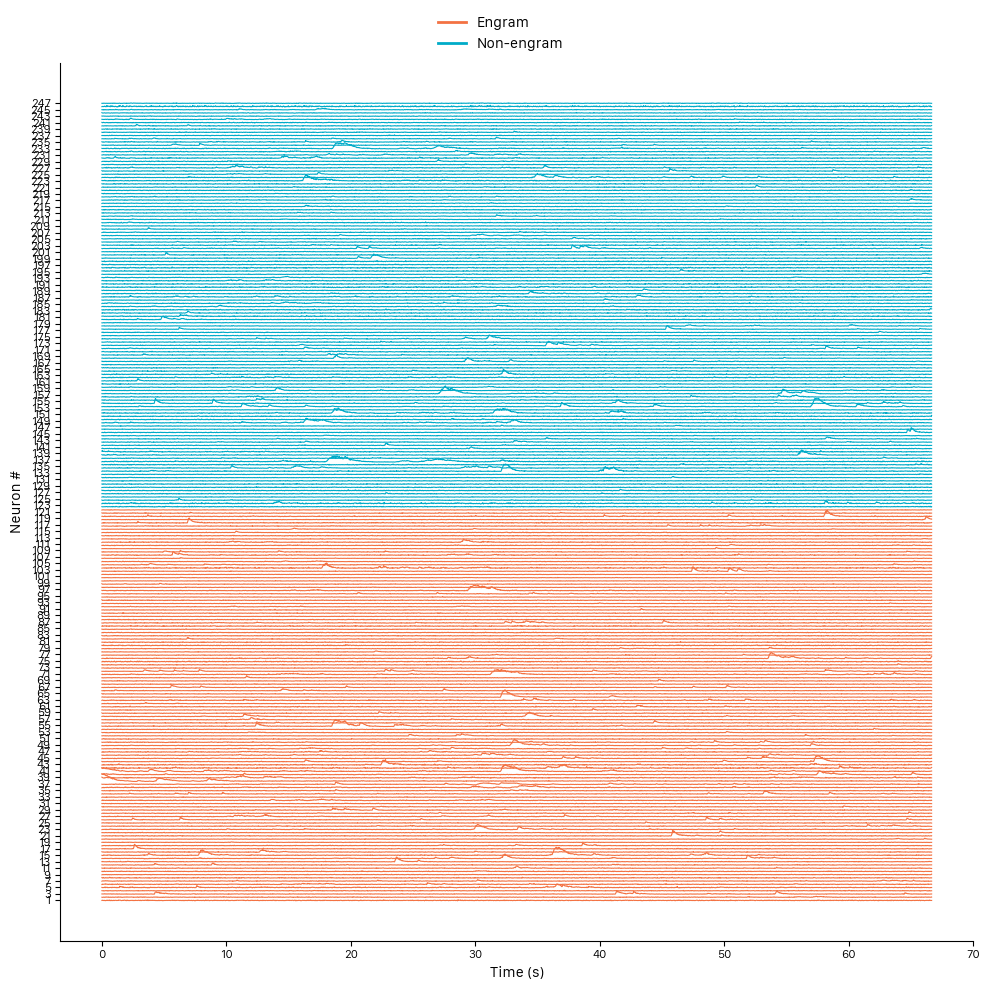

In [6]:
mpl.rcParams['font.family']='Galvji'
tmin,tmax=29000,31000
times = np.linspace(0,(tmax-tmin)/30,tmax-tmin)
fig,ax=plt.subplots(nrows=1,ncols=1,figsize=(10,10))

dffs = np.concatenate((dff_mchs[:,tmin:tmax],dff_nons[:,tmin:tmax]))
colors = ['#F37243']*dff_mchs.shape[0]+['#00ABC8']*dff_nons.shape[0]

ridge_plot(dffs,times,overlay=None,trace_spacing=4,ytick_spacing=2,title='Tagged',color=colors,alpha=1,line_width=.8,ax = ax)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.xlabel('Time (s)',fontdict={'size':10})
plt.ylabel('Neuron #',fontdict={'size':10})

legendlines= [Line2D([0], [0], color='#F37243', lw=2),
                Line2D([0], [0], color='#00ABC8', lw=2)]
ax.legend(legendlines,['Engram','Non-engram'],bbox_to_anchor=(.4,1),fontsize=10,frameon=False)
plt.tight_layout()

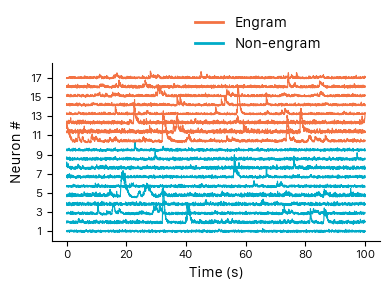

In [19]:
mpl.rcParams['font.family']='Galvji'
mpl.rcParams["svg.fonttype"]='none'
tmin,tmax=29000,32000
times = np.linspace(0,(tmax-tmin)/30,tmax-tmin)
fig,ax=plt.subplots(nrows=1,ncols=1,figsize=(4,3))
mch = dff_mchs[40:48]
non = dff_nons[10:20]
dffs = np.concatenate((non[:,tmin:tmax],mch[:,tmin:tmax]))
colors = ['#00ABC8']*non.shape[0]+['#F37243']*mch.shape[0]

ridge_plot(dffs,times,overlay=None,trace_spacing=2.5,ytick_spacing=2,title='Tagged',color=colors,alpha=1,line_width=.8,ax = ax)
plt.yticks(fontsize=8)
plt.xticks(fontsize=8)
plt.xlabel('Time (s)',fontdict={'size':10})
plt.ylabel('Neuron #',fontdict={'size':10})

legendlines= [Line2D([0], [0], color='#F37243', lw=2),
                Line2D([0], [0], color='#00ABC8', lw=2)]
ax.legend(legendlines,['Engram','Non-engram'],bbox_to_anchor=(.4,1),fontsize=10,frameon=False)
plt.tight_layout()
plt.savefig('/Users/amonast/Dropbox (BOSTON UNIVERSITY)/Manuscripts/Engram2P/Figures/Figure1_method/Fig1E_traces.svg',transparent=True)

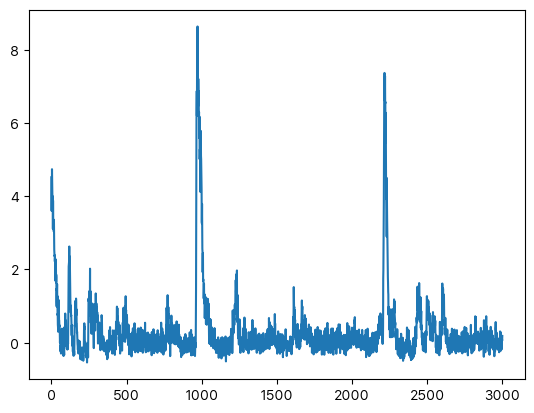

In [17]:
plt.plot(mch[0,tmin:tmax])